In [1]:
import os,sys
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import pingouin as pg
import crispat as cr
import matplotlib.pyplot as plt
import anndata as ad
from plotnine import *
from functools import reduce
from statsmodels.stats.multitest import multipletests
from pathlib import Path
from tqdm.auto import tqdm
import re
import glob
from anndata.experimental.multi_files import AnnCollection
from scipy import stats, sparse

In [202]:
sys.path.insert(0, '/Users/chandrima.modak/CRISPRai-GW/src')

In [3]:
import preprocess as ppr
import preprocess_macs as ppr_m

## Preprocessing

In [ ]:
xadata = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/tregpilot/sample_filtered_feature_bc_matrix.h5'

In [ ]:
gex_a, crispr_a = ppr._split_assay(xadata,'crispr', 'tregfox3', 'lane1')

In [ ]:
ppr_m.get_sgrna_qc_metrics_macs(crispr_a, min_sgrna_counts=3, q=0.05)

In [ ]:
# Process scRNA adata
gex_a.layers['counts'] = gex_a.X.copy()
gex_a, pre_count, post_count = ppr._basic_qc_gex(gex_a)
sc.pp.normalize_total(gex_a)
sc.pp.log1p(gex_a)

In [6]:
sample_outdir = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/tregpilot'

In [ ]:
gex_a.write_h5ad(os.path.join(sample_outdir, "treg_gex_preprocessed.h5ad"))
crispr_a.write_h5ad(os.path.join(sample_outdir, "treg_crispr_preprocessed.h5ad"))
with open(os.path.join(sample_outdir, "stats_report.txt"), "w", encoding="utf-8") as file:
    file.write(f"Pre filter cells count: {pre_count}\n")
    file.write(f"Post filter cells count: {post_count}\n")

## Guide Assignment
The segment computationally intensive if your library size is >2000 guides and multiple. Please avoid this part, you might end up breaking your system and your soul.

import guide_assignment as ga

In [5]:
crispr_a = sc.read_h5ad('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/Jun_project/juns_revision/C4_lib_only_restim_lane3/C4_lib_only_restim_crispr_preprocessed.h5ad')
# gex_a = sc.read('')
sample_outdir = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/Jun_project/juns_revision/C4_lib_only_restim_lane3/'

In [7]:
crispr_a.var

,sgrna_id,perturbed_gene_name,feature_types,genome,pattern,read,sequence,n_cells,mean_counts,total_counts,nonz_means
TNFAIP3_sgRNA_1,TNFAIP3_sgRNA_1,TNFAIP3,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,CTCTGAGCACTCATGGCATA,384,0.089324,2316.0,6.031250
TNFAIP3_sgRNA_2,TNFAIP3_sgRNA_2,TNFAIP3,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,CGGTCTCTGTTAACAAGTGG,300,0.071699,1859.0,6.196667
TNFAIP3_sgRNA_3,TNFAIP3_sgRNA_3,TNFAIP3,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,CTGGCAACTGGAGTCTCTCA,274,0.060822,1577.0,5.755475
TNFAIP3_sgRNA_4,TNFAIP3_sgRNA_4,TNFAIP3,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,TTCGTTTTCAGCGCCACAAG,249,0.064255,1666.0,6.690763
TNFAIP3_sgRNA_5,TNFAIP3_sgRNA_5,TNFAIP3,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,TCTGAGGATGTTGCAAAGGA,250,0.072084,1869.0,7.476000
...,...,...,...,...,...,...,...,...,...,...,...
IFNG_-_68553465.23-P1P2,IFNG_-_68553465.23-P1P2,IFNG,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,TTGGACCTGATCAGCTTGAC,0,0.000000,0.0,0.000000
IFNG_+_68553526.23-P1P2,IFNG_+_68553526.23-P1P2,IFNG,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,CCTCTGGCTGCTGGTATTTC,0,0.000000,0.0,0.000000
IFNG_-_68553535.23-P1P2,IFNG_-_68553535.23-P1P2,IFNG,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,GAGGAGGTGCAGCACATTGC,0,0.000000,0.0,0.000000
IFNG_+_68553203.23-P1P2,IFNG_+_68553203.23-P1P2,IFNG,CRISPR Guide Capture,,TTCCAGCTTAGCTCTTAAAC(BC),R2,ATCAGAGATGCTACAGCAAC,0,0.000000,0.0,0.000000


In [8]:
guide_assign = ga.assign_sgrna(sample_outdir, crispr_a)
guide_assign.run_guide_assign()

Creating subdirectories for model plots...
Directory created: /Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/Jun_project/juns_revision/C4_lib_only_restim_lane3/loss_plots
Directory created: /Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/Jun_project/juns_revision/C4_lib_only_restim_lane3/fitted_model_plots
SPTLC2_sgRNA_3 has only 0 cells with non-zero counts, so no model is fitted for that gRNA
LCP2_sgRNA_6 has only 0 cells with non-zero counts, so no model is fitted for that gRNA
NTCTRL_sgRNA_9 has only 0 cells with non-zero counts, so no model is fitted for that gRNA
ACAT1_+_107992288.23-P1P2_CRISPRi has only 0 cells with non-zero counts, so no model is fitted for that gRNA
ACAT1_A_CRISPRi_1 has only 0 cells with non-zero counts, so no model is fitted for that gRNA
ACTB_-_5570191.23-P1P2_CRISPRi has only 0 cells with non-zero counts, so no model is fitted for that gRNA
ACTB_A_CRISPRi_1 has only 0 cells with non-zero counts, so no model is fitted for that gRNA
ADORA

(                                                    cell             gRNA  \
 0      AAACCAATCACGTTATATCCCAAC-1_lane3_C4_lib_only_t...  TNFAIP3_sgRNA_1   
 1      AAAGGTGAGGACAAGAATCCCAAC-1_lane3_C4_lib_only_t...  TNFAIP3_sgRNA_1   
 2      AACCAGGTCTTACTCCATCCCAAC-1_lane3_C4_lib_only_t...  TNFAIP3_sgRNA_1   
 3      AACGGTTAGTTACACTATCCCAAC-1_lane3_C4_lib_only_t...  TNFAIP3_sgRNA_1   
 4      AACTAACCATAGGGTCATCCCAAC-1_lane3_C4_lib_only_t...  TNFAIP3_sgRNA_1   
 ...                                                  ...              ...   
 25833  TTAAGCTTCGCTTGCGATCCCAAC-1_lane3_C4_lib_only_t...  NTCTRL_sgRNA_52   
 25834  TTAAGGTCACTAACGAATCCCAAC-1_lane3_C4_lib_only_t...  NTCTRL_sgRNA_52   
 25835  TTCCATTGTATTACCAATCCCAAC-1_lane3_C4_lib_only_t...  NTCTRL_sgRNA_52   
 25836  TTCTATCGTCAACATCATCCCAAC-1_lane3_C4_lib_only_t...  NTCTRL_sgRNA_52   
 25837  TTGTGATTCTATCTGGATCCCAAC-1_lane3_C4_lib_only_t...  NTCTRL_sgRNA_52   
 
        UMI_counts  
 0             9.0  
 1            11.0  

In [ ]:
binary_matrix = guide_assign.binary_obsm()

# assign guides to cells
assignment_crispat = guide_assign.merge_guide_assign()

if assignment_crispat.empty:
print(f"No assignments for {value}_{colname}, skipping write.")
return (colname, value)

# --- align assignment_crispat to gex_adata.obs ---
common_cells = assignment_crispat.index.intersection(gex_adata.obs.index)
assignment_crispat = assignment_crispat.loc[common_cells].copy()

if assignment_crispat.index.has_duplicates:
assignment_crispat = assignment_crispat[
~assignment_crispat.index.duplicated(keep="first")
]

# --- target_gene parsing ---
is_multi = assignment_crispat["guide_id"].astype(str).eq("multi_sgRNA")

assignment_crispat.loc[~is_multi, "target_gene"] = (
assignment_crispat.loc[~is_multi, "guide_id"]
.astype(str)
.str.replace("-", "_")
.str.split("_")
.str[0]
)
assignment_crispat.loc[is_multi, "target_gene"] = "multi_sgRNA"

# --- join onto obs ---
gex_adata.obs = gex_adata.obs.join(
assignment_crispat[["gRNA", "guide_id", "target_gene", "UMI_counts"]],
how="left",
)
# Align to adata.obs_names
binary_matrix = binary_matrix.reindex(index=gex_adata.obs_names, fill_value=0)

# Store sparse
gex_adata.obsm['guide_matrix'] = sparse.csr_matrix(binary_matrix.to_numpy(dtype="int8"))
gex_adata.uns["guide_matrix_cols"] = binary_matrix.columns.to_list()

# # Remove cells with UMI_counts less than 3
# keep = gex_adata.obs.UMI_counts >=3
# gex_adata = gex_adata[keep,:].copy()

# Save outputs
assignment_crispat.to_csv(
os.path.join(directory_path, f"{value}_processed_guide.csv")
)
gex_adata.write_h5ad(
os.path.join(directory_path, f"{value}_gex_guide.h5ad")
)

# Plotting on Guide type distribution and efficiency of guides

In [153]:
def classify_sgrna(df):
    df['sgRNA_type'] = 'single sgRNA'
    # overwrite where gRNA is missing
    df.loc[df['guide_id'].isna(), 'sgRNA_type'] = 'no sgRNA'
    df.loc[df['guide_id'].str.startswith('NTC', na=False), 'sgRNA_type'] = 'single NTC sgRNA'
    df.loc[df['guide_id'].str.startswith('multi', na=False), 'sgRNA_type'] = 'multi sgRNA'
    # Order the rows
    type_order = ['single sgRNA','single NTC sgRNA','multi sgRNA','no sgRNA']
    df['sgRNA_type'] = pd.Categorical(df['sgRNA_type'],categories=type_order,ordered=True)
    df = df.loc[:, ['gRNA', 'guide_id', 'UMI_counts', 'target_gene','sgRNA_type']]
    return df

In [172]:
def plot_lane_sgRNA(df):
    p = (
        ggplot(df, aes(x = 'experiment', fill = 'sgRNA_type'))
        + geom_bar(position="stack")
        + scale_fill_brewer(type='sequential', palette= 5, direction= -1)
        + labs(x = 'Experiment lanes',
              y = 'Cell counts')
        + theme_bw()
        + theme(figure_size=(3, 4),
                legend_title=element_blank(),
                axis_text_x=element_text(rotation=90, 
                                         hjust=1))
        + theme(
            plot_title=element_text(size=16, face="bold", ha='center'),
            axis_title_x=element_text(size=18),
            axis_title_y=element_text(size=18),
            axis_text_x=element_text(size=10),
            axis_text_y=element_text(size=10)
            )
        )
    return p

In [144]:
path_adata = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/tregpilot/tregfox3_gex_guide.h5ad'
adata= sc.read_h5ad(path_adata)

In [165]:
guide_ty_df = adata.obs[['gRNA', 'guide_id', 'UMI_counts', 'target_gene']]
guide_ty_df['experiment'] = adata.obs.library_id.unique()[0]+ ' ' + adata.obs.lane_id.unique()[0]

In [166]:
guide_ty_df = classify_sgrna(guide_ty_df)
guide_ty_df

,experiment,gRNA,guide_id,UMI_counts,target_gene,sgRNA_type
AAACAAGCAACAGGCTAAGTAGAG-1_lane1_tregfox3,tregfox3 lane1,PCSK5-2,PCSK5-2,103.0,PCSK5,single sgRNA
AAACAAGCAACCATTCACAGTCTG-1_lane1_tregfox3,tregfox3 lane1,UQCRHL-2,multi_sgRNA,323.0,multi_sgRNA,multi sgRNA
AAACAAGCAACCATTCAGCTGTGA-1_lane1_tregfox3,tregfox3 lane1,KMT2B-2,multi_sgRNA,369.0,multi_sgRNA,multi sgRNA
AAACAAGCAACCATTCAGTGAGTG-1_lane1_tregfox3,tregfox3 lane1,CLEC4E-2,CLEC4E-2,15.0,CLEC4E,single sgRNA
AAACAAGCAACCATTCATACGTCA-1_lane1_tregfox3,tregfox3 lane1,S1PR1-1,multi_sgRNA,19.0,multi_sgRNA,multi sgRNA
...,...,...,...,...,...,...
TTTGTGAGTTTGCTCCATTCGGTT-1_lane1_tregfox3,tregfox3 lane1,NaN,NaN,NaN,NaN,no sgRNA
TTTGTGAGTTTGTCAAAACGCCGA-1_lane1_tregfox3,tregfox3 lane1,DMTF1-2,multi_sgRNA,218.0,multi_sgRNA,multi sgRNA
TTTGTGAGTTTGTCAAAAGTAGAG-1_lane1_tregfox3,tregfox3 lane1,LHPP-1,multi_sgRNA,195.0,multi_sgRNA,multi sgRNA
TTTGTGAGTTTGTCAAACAGTCTG-1_lane1_tregfox3,tregfox3 lane1,NTC-953,multi_sgRNA,237.0,multi_sgRNA,multi sgRNA


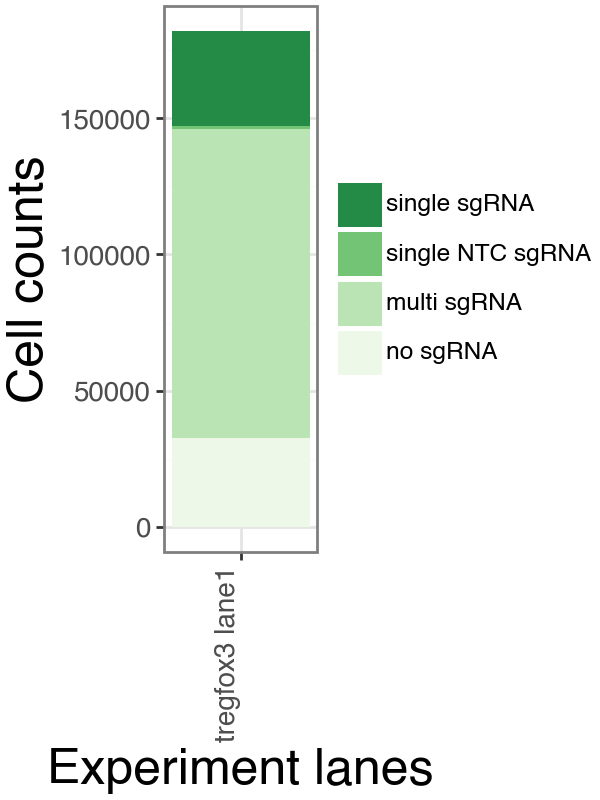

In [173]:
p = plot_lane_sgRNA(guide_ty_df)
p

In [174]:
plt_path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/tregpilot/plots'
os.makedirs(plt_path, exist_ok=True)
p.save(os.path.join(plt_path, "guide_type_distribution.png"), dpi = 300)

In [205]:
import plot_utils as ptu

In [177]:
path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/tregpilot/tregfox3_guide_count_info.csv

In [179]:
df_guide_effi = pd.read_csv(path).set_index('guide_id')
df_guide_effi

,target_gene,n_cells,sum_guide,sumsq_guide,ntc_cells,sum_ntc,sumsq_ntc
guide_id,,,,,,,
A2M-1,A2M,27,0.000000,0.000000,1437,0.000000,0.000000
A2M-2,A2M,18,0.000000,0.000000,1437,0.000000,0.000000
AAAS-1,AAAS,15,5.104083,7.617648,1437,1150.920654,1430.256226
AAAS-2,AAAS,21,4.167954,2.922894,1437,1150.920654,1430.256226
AACS-1,AACS,79,42.545166,45.067955,1437,1148.536621,1528.352295
...,...,...,...,...,...,...,...
ZYX-1,ZYX,1,0.659689,0.435190,1437,1452.918945,2118.816406
ZYX-2,ZYX,21,4.291653,4.046723,1437,1452.918945,2118.816406
ZYX-3,ZYX,14,6.677537,6.874900,1437,1452.918945,2118.816406


In [215]:
df_guide_effi_fdr = ptu.compute_stats_ko(df_guide_effi)
df_guide_effi_fdr = df_guide_effi_fdr.reset_index()
# Removing the guides with low expressing genes 
df_guide_effi_fdr = df_guide_effi_fdr[~df_guide_effi_fdr.effect_size.isna()]

In [216]:
df_guide_effi_fdr = ptu.find_signi_ko(df_guide_effi_fdr)

In [217]:
gene_ntc_means = df_guide_effi_fdr.groupby('target_gene')['ntc_mean'].mean()

# Rank the perturbed genes by their mean NTC expression, using method='first' to handle ties
gene_ranks = gene_ntc_means.rank(method='first')

df_guide_effi_fdr['rank'] = df_guide_effi_fdr['target_gene'].map(gene_ranks)

# Calculate fraction of significant knockdowns and mean expression in bins of 100 ranks
df_guide_effi_fdr['rank_bin'] = pd.qcut(df_guide_effi_fdr['rank'], q=len(df_guide_effi_fdr)//100, labels=False)


In [228]:
df_guide_effi_fdr[(df_guide_effi_fdr['rank'].astype(int) > 1000) & (df_guide_effi_fdr['rank'].astype(int) <1010)]

,guide_id,target_gene,n_cells,sum_guide,sumsq_guide,ntc_cells,sum_ntc,sumsq_ntc,guide_mean,ntc_mean,...,guide_std,ntc_std,fc,t_statistic,p_value,adj_pvals,effect_size,signif_knockdown,rank,rank_bin
1919,BEGAIN-1,BEGAIN,19,0.0,0.0,1437,14.367014,8.557022,0.0,0.009998,...,0.01,0.076543,1.199958,-3.271362,0.000915,0.001917,-0.131434,True,1002.0,19
1920,BEGAIN-2,BEGAIN,24,0.0,0.0,1437,14.367014,8.557022,0.0,0.009998,...,0.01,0.076543,1.199958,-3.482129,0.000387,0.000876,-0.131659,True,1002.0,19
2028,BMP8B-1,BMP8B,6,0.0,0.0,1437,14.643278,9.869894,0.0,0.010190,...,0.01,0.082276,1.203803,-2.203964,0.028868,0.044372,-0.124070,True,1009.0,19
2029,BMP8B-2,BMP8B,24,0.0,0.0,1437,14.643278,9.869894,0.0,0.010190,...,0.01,0.082276,1.203803,-3.420106,0.000450,0.001003,-0.124842,True,1009.0,19
3061,CD14-1,CD14,19,0.0,0.0,1437,14.583658,19.277870,0.0,0.010149,...,0.01,0.115419,1.202974,-2.662092,0.004365,0.007939,-0.088478,True,1006.0,19
3062,CD14-2,CD14,14,0.0,0.0,1437,14.583658,19.277870,0.0,0.010149,...,0.01,0.115419,1.202974,-2.505023,0.007330,0.012722,-0.088326,True,1006.0,19
8033,GRIP1-1,GRIP1,11,0.0,0.0,1437,14.374216,9.537012,0.0,0.010003,...,0.01,0.080878,1.200059,-2.708156,0.006347,0.011154,-0.124109,True,1003.0,19
8034,GRIP1-2,GRIP1,31,0.0,0.0,1437,14.374216,9.537012,0.0,0.010003,...,0.01,0.080878,1.200059,-3.586728,0.000220,0.000522,-0.124965,True,1003.0,19
12917,NSG1-1,NSG1,38,0.0,0.0,1437,14.343260,14.616899,0.0,0.009981,...,0.01,0.100395,1.199628,-3.213850,0.000705,0.001511,-0.100694,True,1001.0,19
12918,NSG1-2,NSG1,27,0.0,0.0,1437,14.343260,14.616899,0.0,0.009981,...,0.01,0.100395,1.199628,-3.048871,0.001300,0.002638,-0.100317,True,1001.0,19


##### Higher the expression of target gene in NTC cells higher the rank

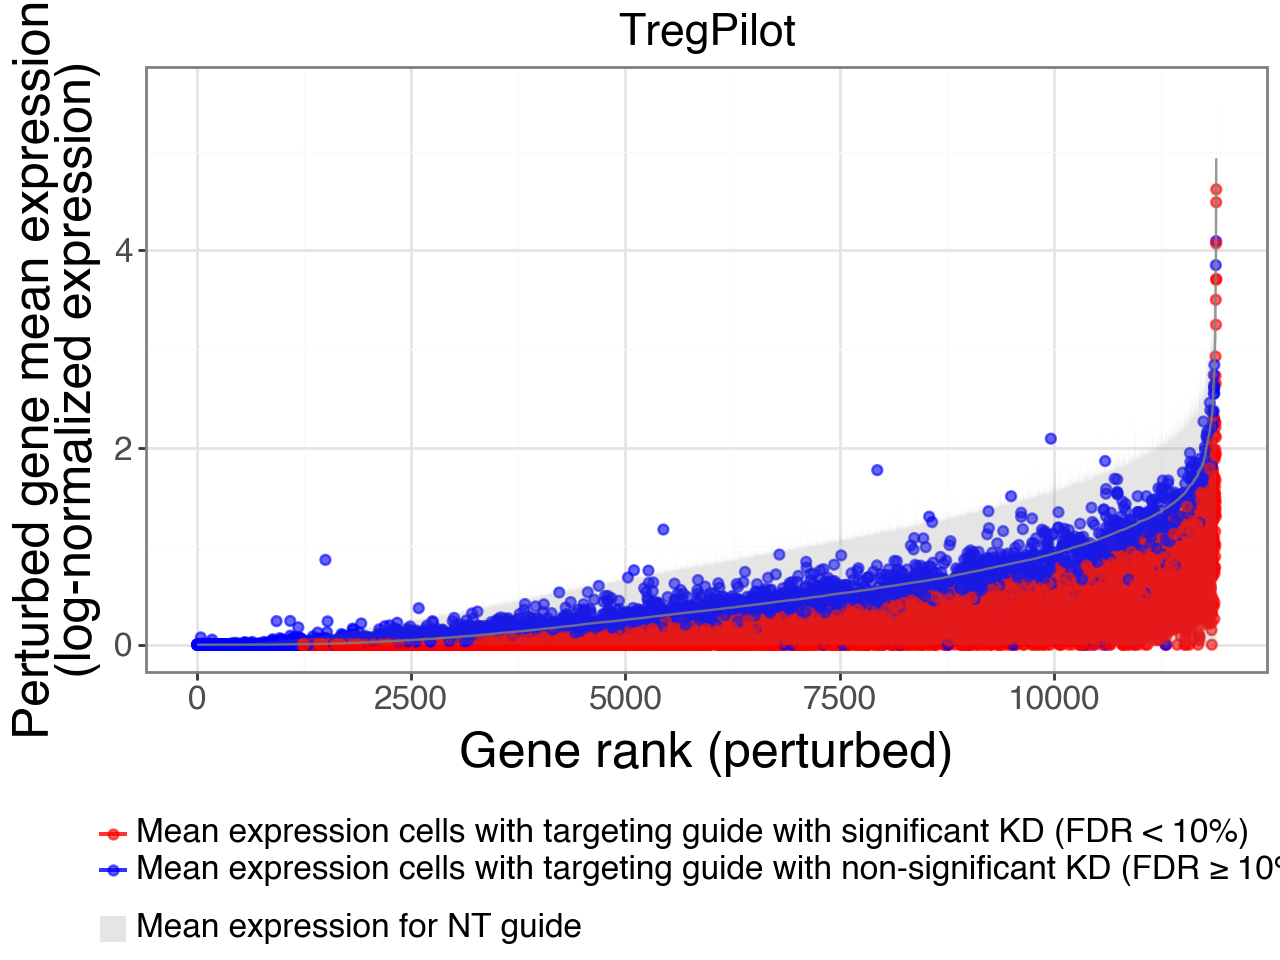

In [200]:
pl_ge = ptu.guide_effect_scatter_plot(df_guide_effi_fdr, 'TregPilot')
pl_ge

In [201]:
bin_stats = df_guide_effi_fdr.groupby('rank_bin').agg({
    'rank': 'mean', 
    'signif_knockdown': 'mean', 
    'guide_mean': 'mean',
    'ntc_mean': 'mean',
    'n_cells': 'mean',
    'target_gene': 'nunique'
    }).reset_index()

In [212]:
def rank_bin_effi(df, sample_name):
    p = (
        ggplot(df, aes(x='rank', y='signif_knockdown'))
        + geom_point(color='black')
        + labs(
            title=f"{sample_name}\nMean target gene expression\n(log-normalized counts)",
            y='Fraction of Effective Guides\n(Significant knockdown, 10% FDR)',
            x='Perturbed genes bin (ranked by mean target expression in NTCs)'
        )
        + theme_bw()
        + theme(
            plot_title=element_text(size=14, face="bold", ha='center'),
            axis_title_x=element_text(size=14),
            axis_title_y=element_text(size=14),
            axis_text_x=element_text(size=12),
            axis_text_y=element_text(size=12)
        )
    )
    return p

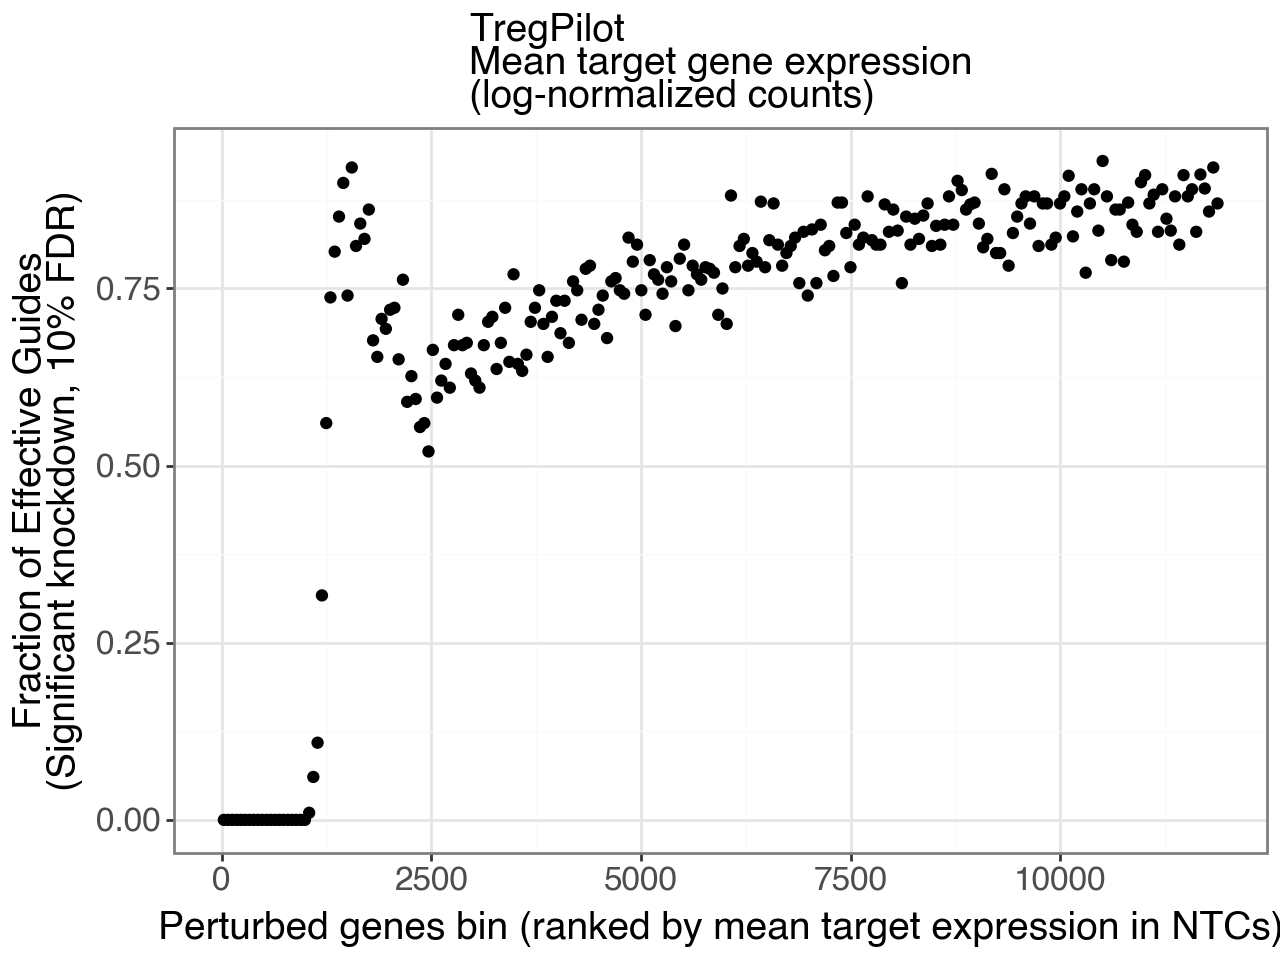

In [213]:
pl_bin = rank_bin_effi(bin_stats, 'TregPilot')
pl_bin

Fraction of guides inducing significant on-target knock-down (y-axis) versus baseline expression of perturbed genes (x-axis). Each point represents 100 genes grouped by similar expression levels. 

### Cells counts distribution for singlets

<Axes: >

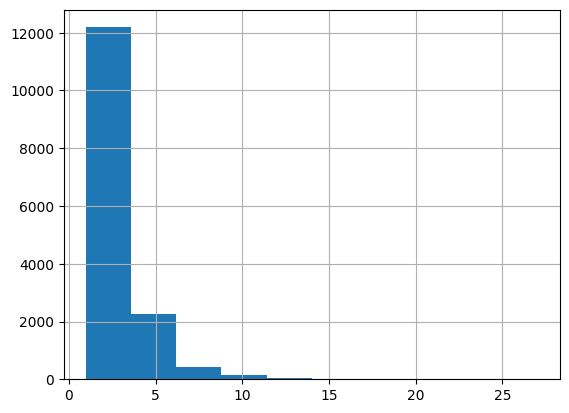

In [241]:
singlets = guide_ty_df[guide_ty_df['sgRNA_type'].str.startswith('single')]
singlets.groupby('guide_id', observed=True).size().hist()

## Cell Annotation

In [246]:
singlets = adata[singlets.index, :].copy()

In [247]:
singlets

AnnData object with n_obs × n_vars = 36175 × 18129
    obs: 'library_id', 'lane_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'gRNA', 'guide_id', 'target_gene', 'UMI_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'guide_matrix_cols', 'log1p'
    obsm: 'guide_matrix'
    layers: 'counts'